# The Harmonic Drive

**A model derived from geometry, material and one tolerance — the second subject of the bench.**

The first notebook in this series derived the capstan from a cable, two radii and a pretension.
This one does the same for the harmonic drive, and it does it under the same discipline:

- **Ratio** comes from two tooth counts — a counting argument, exact.
- **Stiffness** comes from the flexspline cup as a thin-walled shell (Bredt's formula, exact for
  each segment).
- **No-load drag** comes from the wave-generator preload that holds the flexspline in its
  elliptical shape.
- **The 2-per-revolution ripple** comes from *one manufacturing tolerance* — the cam's runout.
- **Efficiency, both directions, comes from the friction of the preloaded bearing and the
  sliding teeth.** As everywhere in this bench, forward and backward efficiency are one knob:
  $\eta_b = 2 - 1/\eta_f$ falls out of the loss model rather than being assumed.

What this cannot tell you, stated before any plot appears: nothing about fatigue (the flexspline
allowable is a documented surrogate), nothing about the near-zero-load softening of the real
hysteresis loop, and the derived stiffness lands *stiffer* than published figures because radial
rim flexure has no closed form — the gap is reported here instead of hidden.

## 1. Every transmission is the same kind of object

The bench rests on one idea: whatever is inside it, a transmission is a **two-port element**
between a motor and a load, completely described by five behaviours.

| | quantity | where drives differ |
|---|---|---|
| 1 | ratio + kinematic error $\;\theta_{out} = \theta_m/N + e(\theta_m)$ | harmonic: 2 cycles/input rev · cycloidal: lobe frequency · capstan: ~0 |
| 2 | compliance $\;K(\delta)$ | harmonic: flexspline windup · capstan: cable $EA$ |
| 3 | loss $\;\tau_{loss}(\tau_j,\omega)$ | the asymmetry here *is* backdrivability |
| 4 | reflected inertia $\;N^2 J_m$ | dominates impact behaviour |
| 5 | limits $\;\tau_{max}$, stroke, slip | a capstan slips; gears do not |

Non-dimensionalizing on the **plant** — $\tau^* = mgL$, $t^* = \sqrt{J_l/mgL}$ — collapses any
drive to six numbers:

$$\Pi_J = \frac{N^2 J_m}{J_l}, \quad
\Omega_n = \sqrt{\frac{K_{out}}{mgL}}, \quad
\zeta_d, \quad \eta_f, \quad \hat\tau_{max}, \quad e(\cdot)$$

Two drives landing on the same six are indistinguishable to the load. The harmonic drive is a
`HarmonicDrive` in `drivelab/drives/harmonic.py`; every number below is computed, not quoted.

In [1]:
import sys, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from drivelab import Config, viz
from drivelab.drives import HarmonicDrive, CapstanDrive, CycloidalDrive
from drivelab.catalog import MOTORS, CABLES, ARMS
from drivelab.catalog.configs import (reference_capstan, reference_harmonic,
                                      reference_cycloidal, harmonic_like,
                                      cycloidal_like)
from drivelab.bench import run_suite, summary_row, resonance_pair

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
print("ready")

ready


## 2. The closed forms worth knowing

### Ratio

The circular spline has $z_c$ teeth and the flexspline $z_f$, with $z_c - z_f = 2$ (one tooth
per wave of the two-lobe wave generator). Per wave-generator turn the flexspline falls behind
by $z_c - z_f$ teeth, so

$$\boxed{\;N = \frac{z_f}{z_c - z_f} = \frac{z_f}{2}\;}$$

a 100:1 drive is a 200-tooth flexspline inside a 202-tooth ring. **The ratio is exact** — it is a
counting argument, not a friction argument.

### Stiffness

Torque enters through the toothed rim, crosses the shallow cone, and winds the thin cup. Each
segment is a closed thin-walled tube, so Bredt's torsion formula applies to every one of them
exactly:

$$\boxed{\;
K_{cup} = \frac{2\pi G\, r^3 t}{L} \qquad
K_{cone} = \frac{4\pi G\, t\,\sin\alpha}{1/a^2 - 1/b^2}
\;}$$

with $a, b$ the cone's end radii and $\alpha$ its half-angle (the cone formula degenerates to the
straight-tube one as $a \to b$). The segments carry the same torque in series, so
$K_{out} = 1/\sum 1/K_i$. The compliance this deliberately does *not* capture is radial flexure
of the toothed rim under load — a shell problem with no useful closed form. The comparison with
published figures below reports the resulting gap.

### No-load drag

The wave generator is an interference fit: it must deflect the rim by $w_0$ to stay engaged, and
that preload costs drag forever, loaded or not. The rim ring resists the two-lobe deflection with
$9EI/r^4$ per unit circumference (extensionless in-plane bending), so

$$\boxed{\;F_p = \frac{9\pi E I_{rim} w_0}{2 r^4}, \qquad
\tau_{c0} = N\,(2\,\mu_{wg} F_p r_b + \tau_{seal})\;}$$

### Ripple

An ideal harmonic drive has zero transmission error — again, the ratio is a counting argument.
The 2-cycles-per-input-revolution ripple everyone measures therefore **enters through
manufacture**: the cam's runout moves the two engagement zones, and the first-order angular error
is the runout over the pitch radius, $\varepsilon = \Delta e / r_p$. Derived here from one
tolerance, not typed in.

### Torque capacity

The flexspline cup fails in shear where it meets the cone:
$\tau_{max} = 2\pi r_{cup}^2 t\,\tau_{allow}$ with $\tau_{allow} = 0.577\,\sigma_{allow}/sf$.
The allowable is a fatigue surrogate — real flexsplines die of crack growth, and this bench has no
fatigue model.

In [2]:
# A size-typical drive (200-tooth flexspline, pitch radius 22 mm, 0.5 mm cup),
# and each closed form evaluated against the hand formula.
h = HarmonicDrive(z_flex=200, r_pitch=0.022, rim_width=8e-3,
                  cup_wall=0.5e-3, cup_length=0.018, rim_wall=0.4e-3,
                  w0=0.4e-3, cone_length=0.007, cone_radii=(0.016, 0.022))

G = h.material.G
k_cup_hand = 2 * math.pi * G * h.cup_radius**3 * h.cup_wall / h.cup_length
k_cone_hand = (4 * math.pi * G * h.cone_wall * h.cone_sin_alpha
               / (1/h.cone_a**2 - 1/h.cone_b**2))
f_p_hand = (9 * math.pi * h.material.E * (h.rim_width * h.rim_wall**3 / 12)
            * h.w0 / (2 * h.r_pitch**4))

print("  ratio:        N = z_f/2 = %g" % h.N)
print("  K_cup:        %.0f N*m/rad   (hand: %.0f)" % (h.k_cup, k_cup_hand))
print("  K_cone:       %.0f N*m/rad   (hand: %.0f)" % (h.k_cone, k_cone_hand))
print("  K_out:        %.0f N*m/rad   (series)" % h.stiffness_out(0))
print("  WG preload:   %.1f N         (hand: %.1f)" % (h.preload_force, f_p_hand))
print("  no-load drag: %.2f N*m at the output (%.0f mN*m at the motor)" % (h._tau_c0, 1e3*h._tau_c0/h.N))
print("  ripple:       %.2f arcmin, 2 cycles per input rev" % (h.summary()["ripple_arcmin"]))
print("  tau_max:      %.1f N*m (cup shear)" % h.tau_max())
print("  eta_f:        %.3f   ->   eta_b = %.3f" % (h.eta_forward, h.summary()["eta_backward"]))
print("  J_extra:      %.4g kg*m^2 output-referred" % h.reflected_inertia_extra())

  ratio:        N = z_f/2 = 100
  K_cup:        55612 N*m/rad   (hand: 55612)
  K_cone:       170934 N*m/rad   (hand: 170934)
  K_out:        41961 N*m/rad   (series)
  WG preload:   206.0 N         (hand: 206.0)
  no-load drag: 0.94 N*m at the output (9 mN*m at the motor)
  ripple:       0.78 arcmin, 2 cycles per input rev
  tau_max:      39.0 N*m (cup shear)
  eta_f:        0.778   ->   eta_b = 0.714
  J_extra:      0.01367 kg*m^2 output-referred


### The honesty check: derived against published

The derived model says this size class should be about 42 kN·m/rad. Class-typical published
figures for a size-20 drive run 8–15 kN·m/rad. The model is **2.7–5× stiffer than reality**,
and the reason is known: the load path through the toothed rim bends the rim radially, and
rim flexure is a shell problem with no closed form — so it is not in the model. The number is
reported anyway, with the gap stated, because hiding the discrepancy would be worse than
having one. Conclusions in this notebook that rest on the *specific* stiffness value inherit
this; conclusions that rest on $N^2 J_m$ and the ratio do not.

## 3. The design fact this model exists to expose

Sweep the cup wall thickness and watch what moves. Stiffness climbs with $t$ — and **strength
climbs with $t$ in exactly the same way**. There is no geometric conflict to trade against: the
harmonic drive's compactness is *paid for* by the wave generator, not by a stiffness-strength
compromise. The real costs appear in the third panel: the preload drag rises with the cube of
the rim thickness, and it is paid forever, at zero load, in every bearing of the drive.

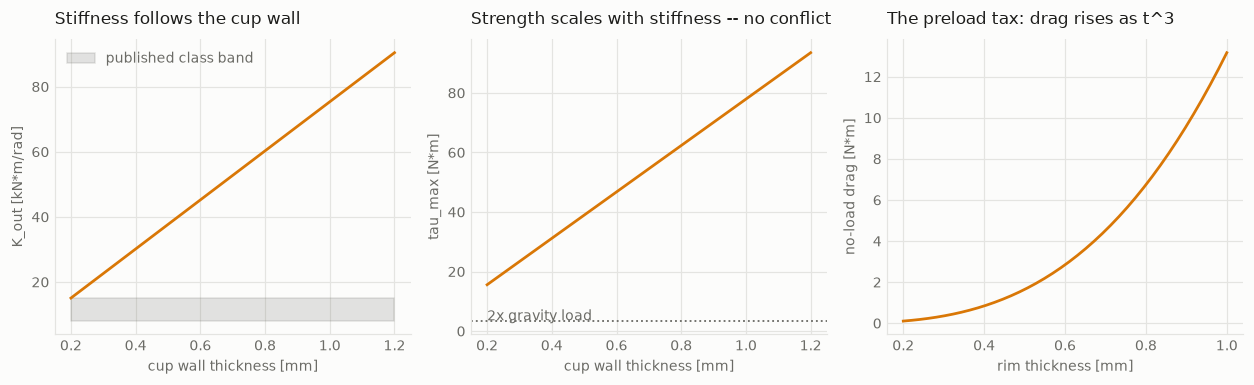

In [3]:
viz.plot_harmonic_tradeoff()
plt.tight_layout(); plt.show()

Read the left two panels together — they are the headline. The capstan hit a hard
bend-ratio cliff where torque, pretension and cable diameter pulled against each other. The
harmonic has *no* such cliff: make the cup thicker and both stiffness and strength improve. That
is exactly why the package can be so compact, and exactly why the trade must show up somewhere
else — in $N^2 J_m$, in backdrivability, and in the preload tax on the right.

In [4]:
# What the three escape routes actually buy.
rows = []
for label, kw in [
    ("reference (0.2 mm cup)",  dict(cup_wall=0.2e-3)),
    ("typical (0.5 mm cup)",   dict(cup_wall=0.5e-3)),
    ("stout (0.8 mm cup)",     dict(cup_wall=0.8e-3)),
    ("tight cam (3 um runout)", dict(cup_wall=0.2e-3, cam_runout=3.0e-6)),
]:
    d = HarmonicDrive(z_flex=200, r_pitch=0.022, rim_width=8e-3,
                      cup_length=0.018, **kw)
    rows.append({
        "design": label,
        "K_out [kN*m/rad]": d.stiffness_out(0) / 1e3,
        "tau_max [N*m]": d.tau_max(),
        "preload drag [N*m]": d.N * 2 * d.mu_wg * d.preload_force * d.r_wg_bearing,
        "ripple [arcmin]": d.summary()["ripple_arcmin"],
        "eta_f": d.eta_forward,
    })
pd.DataFrame(rows).set_index("design")

,K_out [kN*m/rad],tau_max [N*m],preload drag [N*m],ripple [arcmin],eta_f
design,,,,,
reference (0.2 mm cup),16.448840,15.584595,0.842919,0.781306,0.777691
typical (0.5 mm cup),41.122100,38.961487,0.842919,0.781306,0.777691
stout (0.8 mm cup),65.795359,62.338379,0.842919,0.781306,0.777691
tight cam (3 um runout),16.448840,15.584595,0.842919,0.468784,0.777691


## 4. The reference harmonic

Everything from here on uses one specific, inspectable configuration: a harmonic drive *sized to
the arm* — `HarmonicDrive.sized_for` inverts the cup's shear limit for the wall thickness, so the
result is the thinnest (and most compliant) cup that still carries twice the arm's gravity load.

Note what does **not** scale down when you size the drive down to the load: the wave-generator
preload drag (the rim still has to be deflected), and $N^2 J_m$ (the ratio is untouched by
sizing). Those two are the harmonic's floor.

In [5]:
cfg = reference_harmonic()
s = cfg.drive.summary()
for k in ["N", "z_flex", "z_ring", "r_pitch_mm", "cup_wall_mm", "cup_length_mm",
          "K_out", "k_cup", "k_cone", "preload_N", "wg_bearing_drag",
          "tau_max", "ripple_arcmin", "no_load_drag",
          "eta_at_10pct", "eta_at_tau_max"]:
    v = s[k]
    print("  %-20s %s" % (k, ("%.5g" % v) if isinstance(v, float) else v))

print("\n  -- as the load sees it --")
for k, v in sorted(cfg.pi.as_dict().items()):
    print("  %-20s %s" % (k, ("%.5g" % v) if isinstance(v, float) else v))
print("\n  feasibility:", cfg.feasibility() or "ok")

  N                    100
  z_flex               200
  z_ring               202
  r_pitch_mm           22
  cup_wall_mm          0.2
  cup_length_mm        19.8
  K_out                15075
  k_cup                20223
  k_cone               59216
  preload_N            205.99
  wg_bearing_drag      0.84292
  tau_max              15.585
  ripple_arcmin        0.78131
  no_load_drag         0.94292
  eta_at_10pct         0.52885
  eta_at_tau_max       0.74274

  -- as the load sees it --
  Omega_n              94.399
  Pi_J                 24.519
  err_amp_arcmin       0.78131
  eta_b                0.71414
  eta_f                0.77769
  f_resonance_ratio    96.305
  self_locking         False
  tau_max_hat          9.2127
  zeta_d               0.02

  feasibility: ok


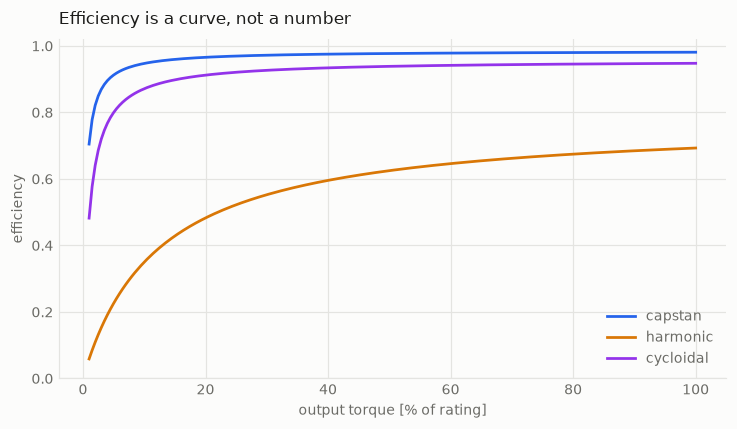

In [6]:
# Efficiency is a curve, not a number -- and the shapes differ by mechanism.
viz.plot_efficiency_curves(
    {"capstan": reference_capstan().drive,
     "harmonic": cfg.drive,
     "cycloidal": reference_cycloidal().drive},
    tau_max=6.0)
plt.tight_layout(); plt.show()

The harmonic's curve sits between the other two: it starts low (the preloaded wave
generator drags at no load) and climbs, but flattens sooner than the capstan's because the
tooth-sliding loss is load-proportional.

## 5. Watching it move

The animation drives the reference harmonic through the lost-motion test. The flexspline is drawn
as the wave generator's two-lobe ellipse; its major axis turns once per input revolution — at
$N$ times the speed of the output. Windup is drawn **exaggerated** (a real flexspline deflects by
arcminutes) and the factor is printed on the figure.

In [7]:
from IPython.display import HTML
from drivelab.bench.tests import t1_lost_motion

r_anim = t1_lost_motion(cfg)
HTML(viz.animate_harmonic(r_anim, stride=25, dpi=64).to_jshtml())

## 6. The standardized tests

Five tests, identical for every drive, times expressed in units of the plant time scale so the
same test is the same test at any scale.

| | test | what it isolates |
|---|---|---|
| **T1** | lost motion | input locked, output pushed slowly back and forth |
| **T2** | cyclic tracking | PD control, *fixed* bandwidth rule for all drives |
| **T3** | backdrive | torque ramp at the output, motor unpowered |
| **T4** | impact | swing into a virtual wall |
| **T5** | frequency | chirp, FRF from motor torque to link angle |

Two deliberate choices, both places where comparisons usually go quietly wrong: **the controller
is fixed** (same `alpha` for everyone — a drive that cannot support it rings or goes unstable,
and that *is* the finding), and **the wall in T4 is referenced to the plant**, so every drive
hits the identical obstacle.

In [8]:
%time results = run_suite(cfg, verbose=True)

  T1   ok


  T2   ok


  T3   ok


  T3s  ok


  T4   ok


  T5   ok
CPU times: user 37.4 s, sys: 30.1 ms, total: 37.4 s
Wall time: 37.5 s


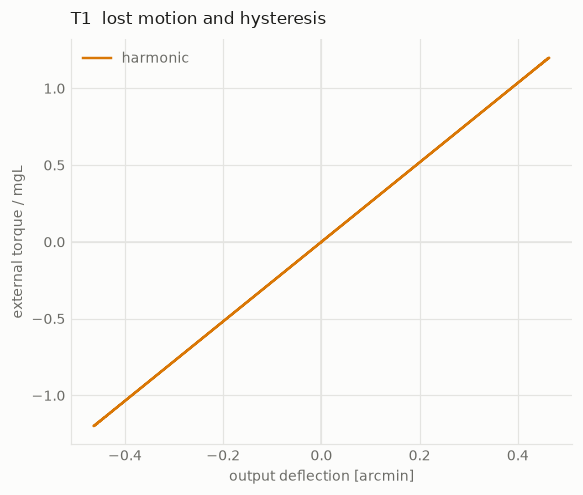

  lost motion       0.0001 arcmin   (preloaded teeth: no deadband, presliding only)
  measured K        15055.3 N*m/rad   vs 15074.6 derived from Bredt  (0.1% difference)
  loss per cycle    6.48e-08 J


In [9]:
viz.plot_hysteresis({"harmonic": results["T1"][0]})
plt.tight_layout(); plt.show()

m = results["T1"][1]
print("  lost motion       %.4f arcmin   (preloaded teeth: no deadband, presliding only)"
      % m["lost_motion_arcmin"])
print("  measured K        %.1f N*m/rad   vs %.1f derived from Bredt  (%.1f%% difference)"
      % (m["stiffness_Nm_rad"], cfg.drive.stiffness_out(0.0),
         100 * abs(m["stiffness_Nm_rad"] / cfg.drive.stiffness_out(0.0) - 1)))
print("  loss per cycle    %.3g J" % m["hysteresis_loss_J"])

That the measured stiffness recovers the derived Bredt value is a check on the
bench, not a result about the drive — but it is the kind of check worth keeping visible. The
near-zero lost motion is the real harmonic property: the wave generator preloads every tooth
into contact, so there is no deadband, only friction presliding.

In [10]:
from drivelab.bench.metrics import t3_metrics

bd = {"open circuit": results["T3"][1], "phases shorted": results["T3s"][1]}
for k, m in bd.items():
    print("  %-16s breakaway %.4f N*m  =  %.3f x mgL  =  %.1f%% of rating"
          % (k, m["backdrive_torque_Nm"], m["backdrive_torque_hat"],
             m["backdrive_pct_rated"]))
print("\n  short-circuit damping kt^2/R = %.3f N*m/(rad/s) at the rotor"
      % cfg.motor.short_circuit_damping)
print("  ... referred to the output:     %.1f N*m/(rad/s)"
      % (cfg.drive.N**2 * cfg.motor.short_circuit_damping))

  open circuit     breakaway 3.4654 N*m  =  2.049 x mgL  =  22.2% of rating
  phases shorted   breakaway 9.9646 N*m  =  5.890 x mgL  =  63.9% of rating

  short-circuit damping kt^2/R = 0.023 N*m/(rad/s) at the rotor
  ... referred to the output:     232.7 N*m/(rad/s)


Both numbers matter, and at 100:1 the second one is the story. The mechanism's
own backdrive threshold — preload drag plus derived mesh loss — is about 2 mgL. The *motor*
referred through $N^2$ adds $k_t^2/R \cdot N^2 \approx 233$ N·m/(rad/s) of damping: the phases
shorted, the same drive refuses to move at all until the ramp is fighting a brake two orders of
magnitude stronger than the drive's own friction. A high-ratio drive is backdrivable only insofar
as its motor lets it be.

In [11]:
m4 = results["T4"][1]
print("  peak transmitted      %.0f N*m  =  %.1f x mgL" %
      (m4["peak_transmitted_Nm"], m4["peak_transmitted_hat"]))
print("  as a fraction of the drive rating:  %.1f" % m4["peak_over_rating"])
print("  momentum from the motor:            %.1f%%" %
      (100 * m4["reflected_momentum_share"]))
print("  did anything slip?                  %s" % m4["slipped"])

  peak transmitted      671 N*m  =  396.6 x mgL
  as a fraction of the drive rating:  43.1
  momentum from the motor:            96.1%
  did anything slip?                  False


No fuse. The capstan's peak sat at exactly 1.00× its rating because the cable
slipped; the harmonic transmits **43× its rating** and keeps every arcsecond of registration. A
geared drive cannot shed an overload — T4 is the test where that difference in kind appears, and
96% of the arriving momentum is the motor's own, carried through $N^2 J_m$.

## 7. What the derived model found

Reading across the table and the figures:

**1. Backdrivability is now predicted, and it lands at $\eta_b \approx 0.71$.** The loss model
is built from the wave-generator bearing under mesh load plus tooth sliding, giving
$\eta_f = 0.78$ and therefore $\eta_b = 2 - 1/0.78 = 0.71$ — no second knob. The datasheet
container assumed 0.75/0.67; the derived model says slightly better.

**2. The derived stiffness is stiffer than published figures** — 2.7–5×, depending on cup
thickness, because radial rim flexure is not in the model. Reported, not hidden. The resonance
*separation* result does not care: it is set by $\Pi_J$ alone.

**3. There is no stiffness-strength conflict — and that is why the package is so compact.**
Thicker cup: stiffer *and* stronger. The harmonic pays for its compactness elsewhere: in
$N^2 J_m$, in the preload tax, and in backdrivability.

**4. The ripple is a tolerance, made visible.** One number — cam runout — produces the classic
2-per-revolution error of about 0.8 arcmin. Tighten the cam, and the ripple shrinks
proportionally; there is no other way to buy it down.

In [12]:
configs = {
    "capstan": reference_capstan(),
    "harmonic": cfg,
    "harmonic (datasheet)": harmonic_like(),
}
rows = []
for name, c in configs.items():
    print("running %s ..." % name)
    rows.append(summary_row(c, run_suite(c)))
pd.DataFrame(rows).set_index("config").T

running capstan ...


running harmonic ...


running harmonic (datasheet) ...


config,capstan 7.7:1 on desktop-300,harmonic 100:1 on desktop-300 (derived),harmonic-100 (datasheet)
derived,True,True,False
N,7.688984,100.0,100.0
Pi_J,0.178749,24.518567,24.242828
Omega_n,51.80209,94.398984,64.327124
eta_f,0.985,0.777691,0.75
eta_b,0.984772,0.714142,0.666667
T1.lost_motion_arcmin,0.000156,0.000053,0.000166
T1.stiffness_hat,2676.069685,8899.760367,4136.201034
T1.hysteresis_loss_hat,0.0,0.0,0.0
T2.rms_error_arcmin,45.505422,49.607939,626.945965


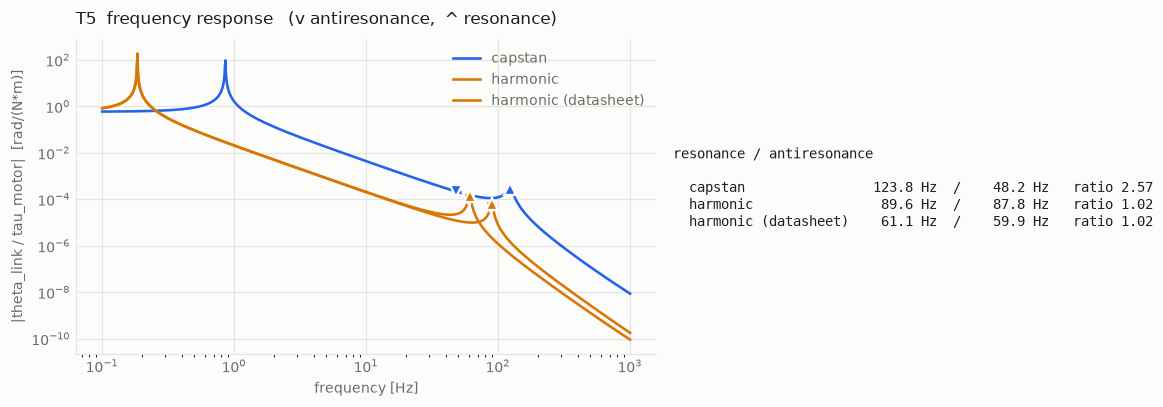

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                         gridspec_kw={"width_ratios": [1.6, 1]},
                         facecolor=viz.SURFACE)
viz.plot_bode(configs, ax=axes[0])
axes[1].axis("off")
sep = {k: resonance_pair(c) for k, c in configs.items()}
txt = "resonance / antiresonance\n\n"
for k, (fa, fr) in sep.items():
    txt += "  %-20s  %6.1f Hz  /  %6.1f Hz   ratio %.2f\n" % (k, fr, fa, fr / fa)
axes[1].text(0, 0.5, txt, family="monospace", fontsize=9,
             color=viz.INK, va="center")
plt.tight_layout(); plt.show()

### Caveats, stated plainly

- The flexspline allowable is a **fatigue surrogate** (reduced stress + safety factor). Real
  drives fail by crack growth; this bench has no fatigue model.
- The derived stiffness omits radial rim flexure and lands above published figures; see §2.
- The near-zero-load softening of real harmonic hysteresis (K1 < K3) is not modelled — it is a
  measured property, not a geometric one.
- No failure model: T4 happily reports the drive transmitting 43× its rating.
- The reference config is sized to a light desktop arm. The 100:1 ratio itself is not resized —
  that mismatch between ratio and load is exactly what $N^2 J_m$ makes visible.

### Next

The companion study is `cycloidal_drive.ipynb`. With both derived, the comparison is
derived-to-derived; the remaining datasheet containers exist for provenance checks only.